# Лабораторная работа № 1 ТМО

# Кудабаева Эвита ИУ5-62Б


# Линейные модели, SVM и деревья решений.
### Цель лабораторной работы: изучение линейных моделей, SVM и деревьев решений.

# Требования к отчету:
Отчет по лабораторной работе должен содержать:

титульный лист;
описание задания;
текст программы;
экранные формы с примерами выполнения программы.

# Задание:
Выберите набор данных (датасет) для решения задачи классификации или регрессии.
В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
С использованием метода train_test_split разделите выборку на обучающую и тестовую.
Обучите следующие модели:
одну из линейных моделей (линейную или полиномиальную регрессию при решении задачи регрессии, логистическую регрессию при решении задачи классификации);
SVM;
дерево решений.
Оцените качество моделей с помощью двух подходящих для задачи метрик. Сравните качество полученных моделей.
Постройте график, показывающий важность признаков в дереве решений.
Визуализируйте дерево решений или выведите правила дерева решений в текстовом виде.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

In [2]:
df = sns.load_dataset('titanic')
data = df.copy()

age_medians = data.groupby('pclass')['age'].median()
def fill_age(row):
    if pd.isnull(row['age']):
        return age_medians[row['pclass']]
    return row['age']
data['age'] = data.apply(fill_age, axis=1)

data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)

cols_to_drop = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
data.drop(columns=[col for col in cols_to_drop if col in data.columns], inplace=True)

data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

bool_cols = data.select_dtypes(include=['bool']).columns
for col in bool_cols:
    data[col] = data[col].astype(int)

data.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,0,1
4,0,3,35.0,0,0,8.0500,1,1,0,1


In [3]:
y = data['survived']
X = data.drop('survived', axis=1)

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(y.value_counts())

Размер X: (891, 9)
Размер y: (891,)
survived
0    549
1    342
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().round(2)

,pclass,age,sibsp,parch,fare,alone,sex_male,embarked_Q,embarked_S
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.57,-2.16,-0.47,-0.47,-0.65,-1.23,-1.36,-0.31,-1.62
25%,-0.37,-0.53,-0.47,-0.47,-0.49,-1.23,-1.36,-0.31,-1.62
50%,0.83,-0.23,-0.47,-0.47,-0.36,0.81,0.74,-0.31,0.62
75%,0.83,0.60,0.43,-0.47,-0.02,0.81,0.74,-0.31,0.62
max,0.83,3.85,6.78,6.97,9.67,0.81,0.74,3.25,0.62


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (712, 9), X_test: (179, 9)
y_train: (712,), y_test: (179,)


In [6]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr))

coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': lr.coef_[0]
}).sort_values('Коэффициент', ascending=False)
print("\nКоэффициенты модели:")
print(coef_df)

Accuracy: 0.8101
F1-score: 0.7385

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

Confusion matrix:
[[97 13]
 [21 48]]

Коэффициенты модели:
      Признак  Коэффициент
7  embarked_Q     0.097119
4        fare     0.080882
8  embarked_S    -0.132469
3       parch    -0.163674
5       alone    -0.287121
2       sibsp    -0.452366
1         age    -0.540453
0      pclass    -0.962096
6    sex_male    -1.235634


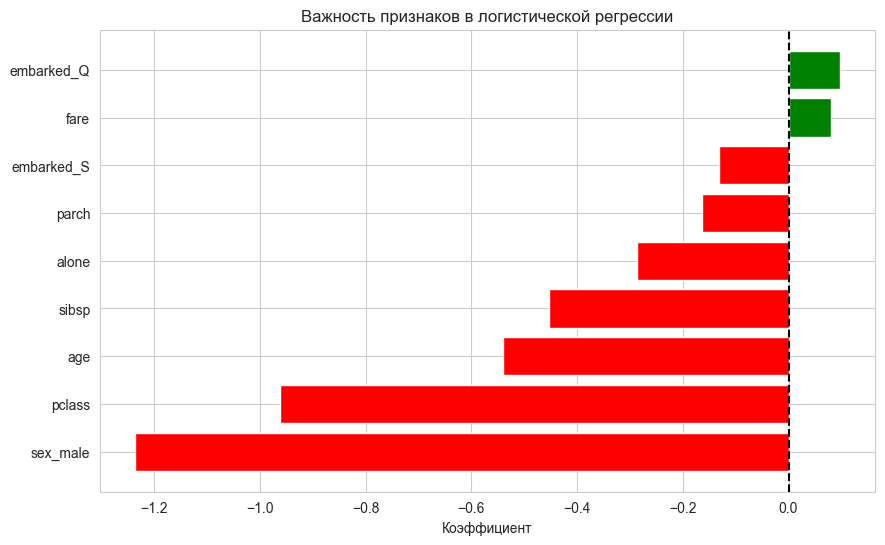

In [7]:
plt.figure(figsize=(10, 6))
coef_df_sorted = coef_df.sort_values('Коэффициент')
colors = ['red' if x < 0 else 'green' for x in coef_df_sorted['Коэффициент']]
plt.barh(coef_df_sorted['Признак'], coef_df_sorted['Коэффициент'], color=colors)
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Коэффициент')
plt.title('Важность признаков в логистической регрессии')
plt.show()

In [9]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"F1-score: {f1_svm:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_svm))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8101
F1-score: 0.7258

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179

Confusion matrix:
[[100  10]
 [ 24  45]]


In [10]:
dt = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_split=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7933
F1-score: 0.6726

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       110
           1       0.86      0.55      0.67        69

    accuracy                           0.79       179
   macro avg       0.82      0.75      0.76       179
weighted avg       0.81      0.79      0.78       179

Confusion matrix:
[[104   6]
 [ 31  38]]


      Признак  Важность
6    sex_male  0.580692
0      pclass  0.197414
1         age  0.107773
4        fare  0.063622
8  embarked_S  0.037482
2       sibsp  0.012201
3       parch  0.000815
5       alone  0.000000
7  embarked_Q  0.000000


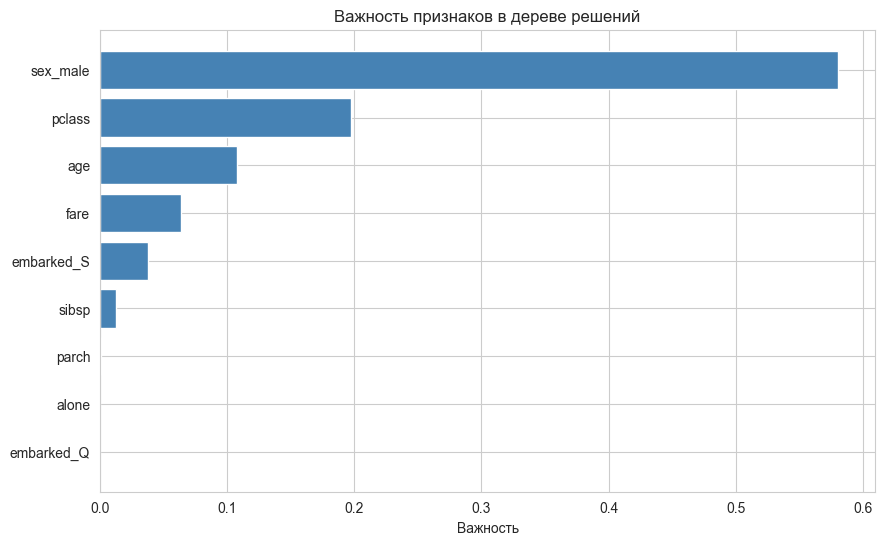

In [11]:
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': dt.feature_importances_
}).sort_values('Важность', ascending=False)

print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'], feature_importance['Важность'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()
plt.show()

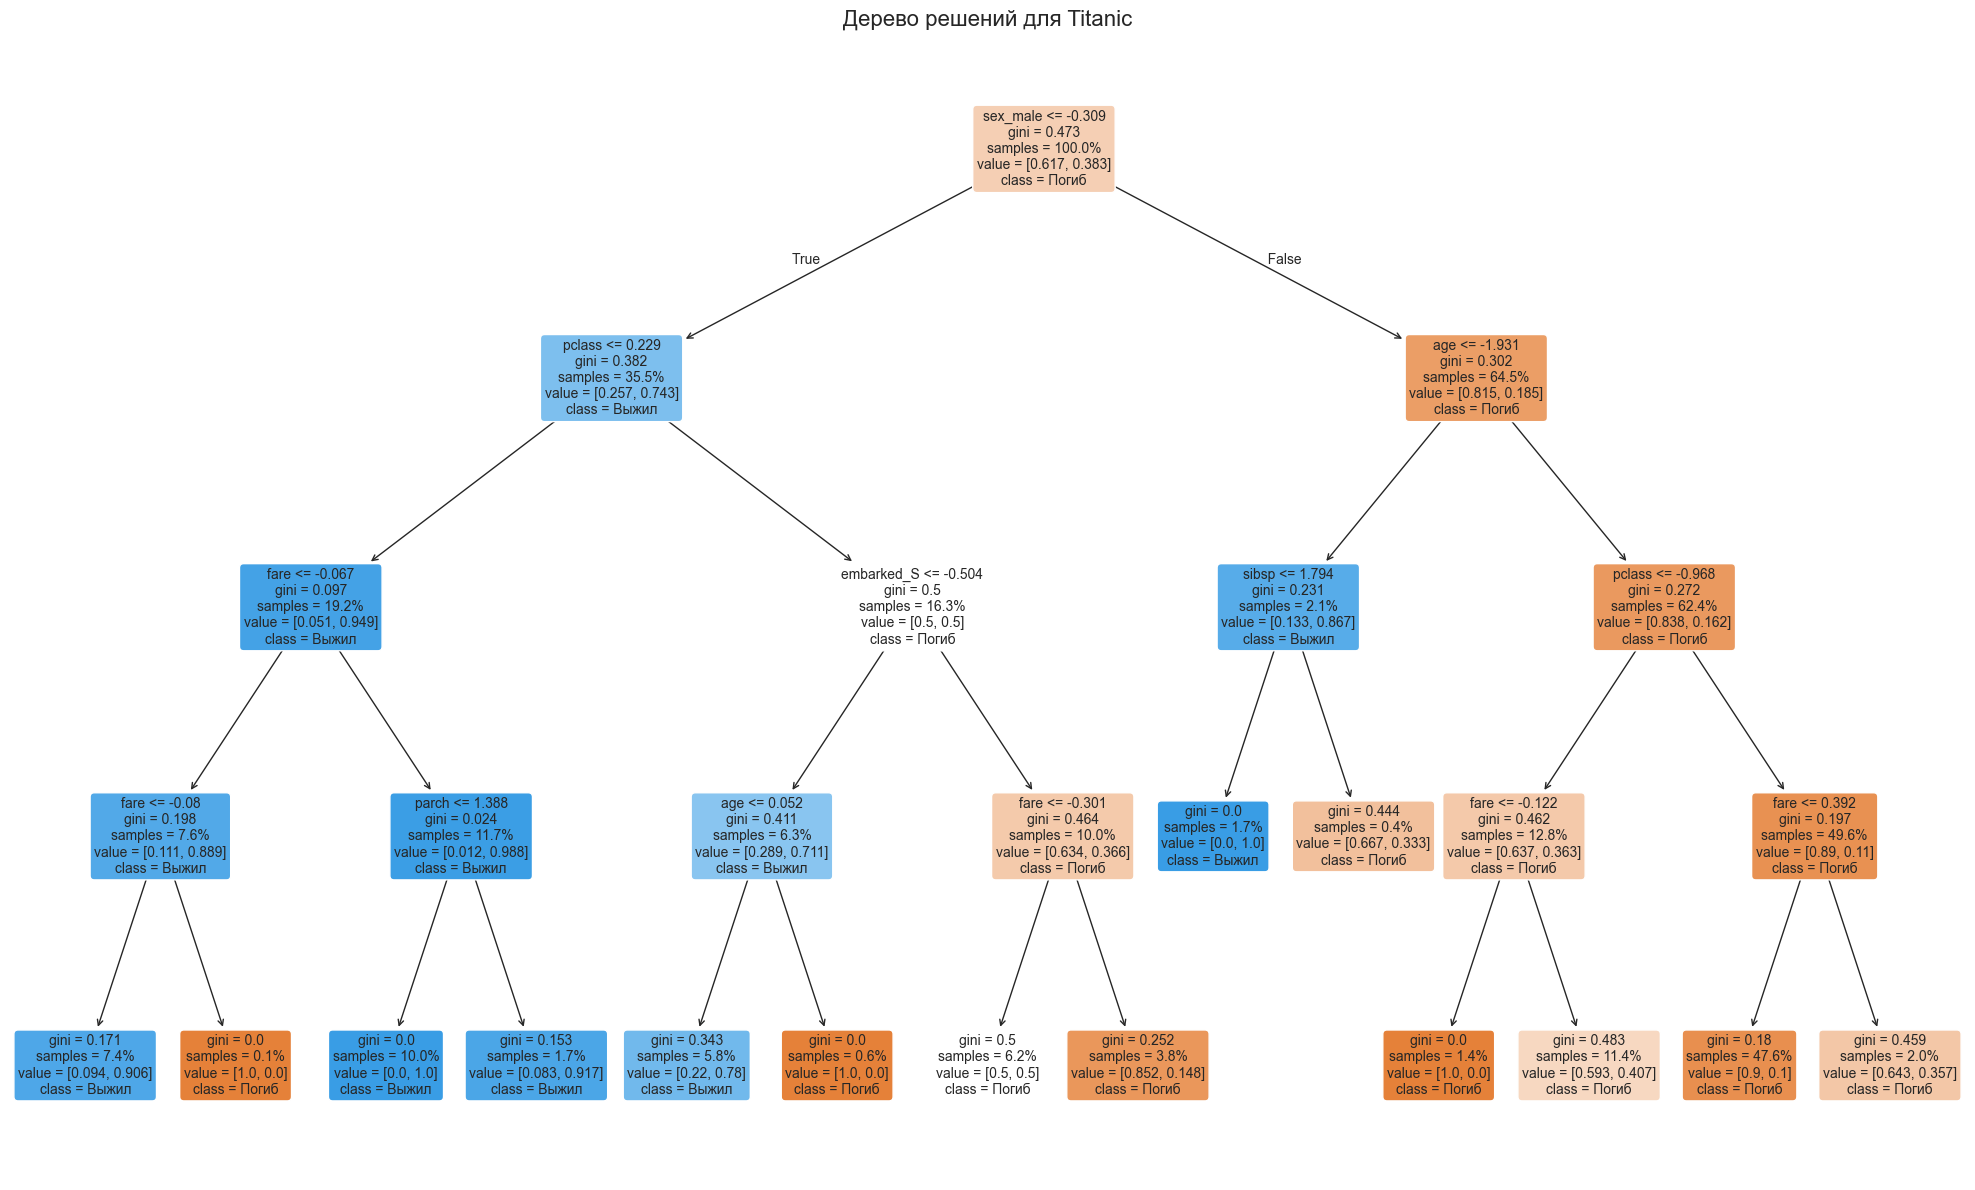

In [12]:
plt.figure(figsize=(20, 12))
plot_tree(dt, 
          feature_names=X.columns,
          class_names=['Погиб', 'Выжил'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title('Дерево решений для Titanic', fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
tree_rules = export_text(dt, feature_names=list(X.columns))
print(tree_rules)

|--- sex_male <= -0.31
|   |--- pclass <= 0.23
|   |   |--- fare <= -0.07
|   |   |   |--- fare <= -0.08
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  -0.08
|   |   |   |   |--- class: 0
|   |   |--- fare >  -0.07
|   |   |   |--- parch <= 1.39
|   |   |   |   |--- class: 1
|   |   |   |--- parch >  1.39
|   |   |   |   |--- class: 1
|   |--- pclass >  0.23
|   |   |--- embarked_S <= -0.50
|   |   |   |--- age <= 0.05
|   |   |   |   |--- class: 1
|   |   |   |--- age >  0.05
|   |   |   |   |--- class: 0
|   |   |--- embarked_S >  -0.50
|   |   |   |--- fare <= -0.30
|   |   |   |   |--- class: 0
|   |   |   |--- fare >  -0.30
|   |   |   |   |--- class: 0
|--- sex_male >  -0.31
|   |--- age <= -1.93
|   |   |--- sibsp <= 1.79
|   |   |   |--- class: 1
|   |   |--- sibsp >  1.79
|   |   |   |--- class: 0
|   |--- age >  -1.93
|   |   |--- pclass <= -0.97
|   |   |   |--- fare <= -0.12
|   |   |   |   |--- class: 0
|   |   |   |--- fare >  -0.12
|   |   |   |   |--- class: 0
|

                    Модель  Accuracy  F1-score
0  Логистическая регрессия    0.8101    0.7385
1                      SVM    0.8101    0.7258
2           Дерево решений    0.7933    0.6726


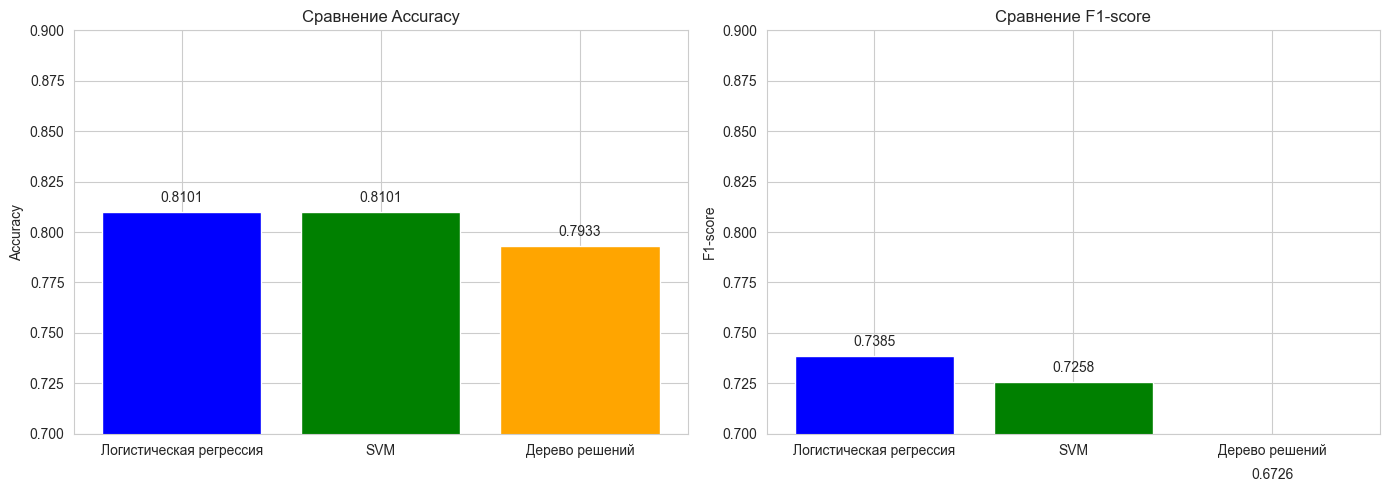

In [14]:
comparison = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'SVM', 'Дерево решений'],
    'Accuracy': [accuracy_lr, accuracy_svm, accuracy_dt],
    'F1-score': [f1_lr, f1_svm, f1_dt]
})

print(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(comparison['Модель'], comparison['Accuracy'], color=['blue', 'green', 'orange'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Сравнение Accuracy')
axes[0].set_ylim([0.7, 0.9])
for i, v in enumerate(comparison['Accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center')

axes[1].bar(comparison['Модель'], comparison['F1-score'], color=['blue', 'green', 'orange'])
axes[1].set_ylabel('F1-score')
axes[1].set_title('Сравнение F1-score')
axes[1].set_ylim([0.7, 0.9])
for i, v in enumerate(comparison['F1-score']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

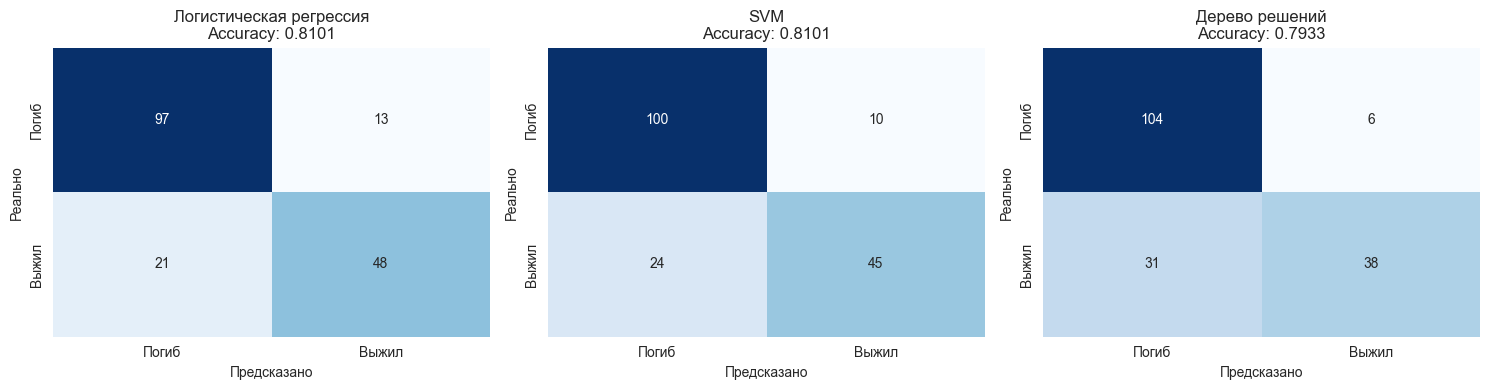

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [lr, svm, dt]
names = ['Логистическая регрессия', 'SVM', 'Дерево решений']

for i, (model, name) in enumerate(zip(models, names)):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}')
    axes[i].set_xlabel('Предсказано')
    axes[i].set_ylabel('Реально')
    axes[i].set_xticklabels(['Погиб', 'Выжил'])
    axes[i].set_yticklabels(['Погиб', 'Выжил'])

plt.tight_layout()
plt.show()

In [16]:
print(f"Логистическая регрессия - Accuracy: {accuracy_lr:.4f}, F1: {f1_lr:.4f}")
print(f"SVM - Accuracy: {accuracy_svm:.4f}, F1: {f1_svm:.4f}")
print(f"Дерево решений - Accuracy: {accuracy_dt:.4f}, F1: {f1_dt:.4f}")

Логистическая регрессия - Accuracy: 0.8101, F1: 0.7385
SVM - Accuracy: 0.8101, F1: 0.7258
Дерево решений - Accuracy: 0.7933, F1: 0.6726
